# Aufgabe 1



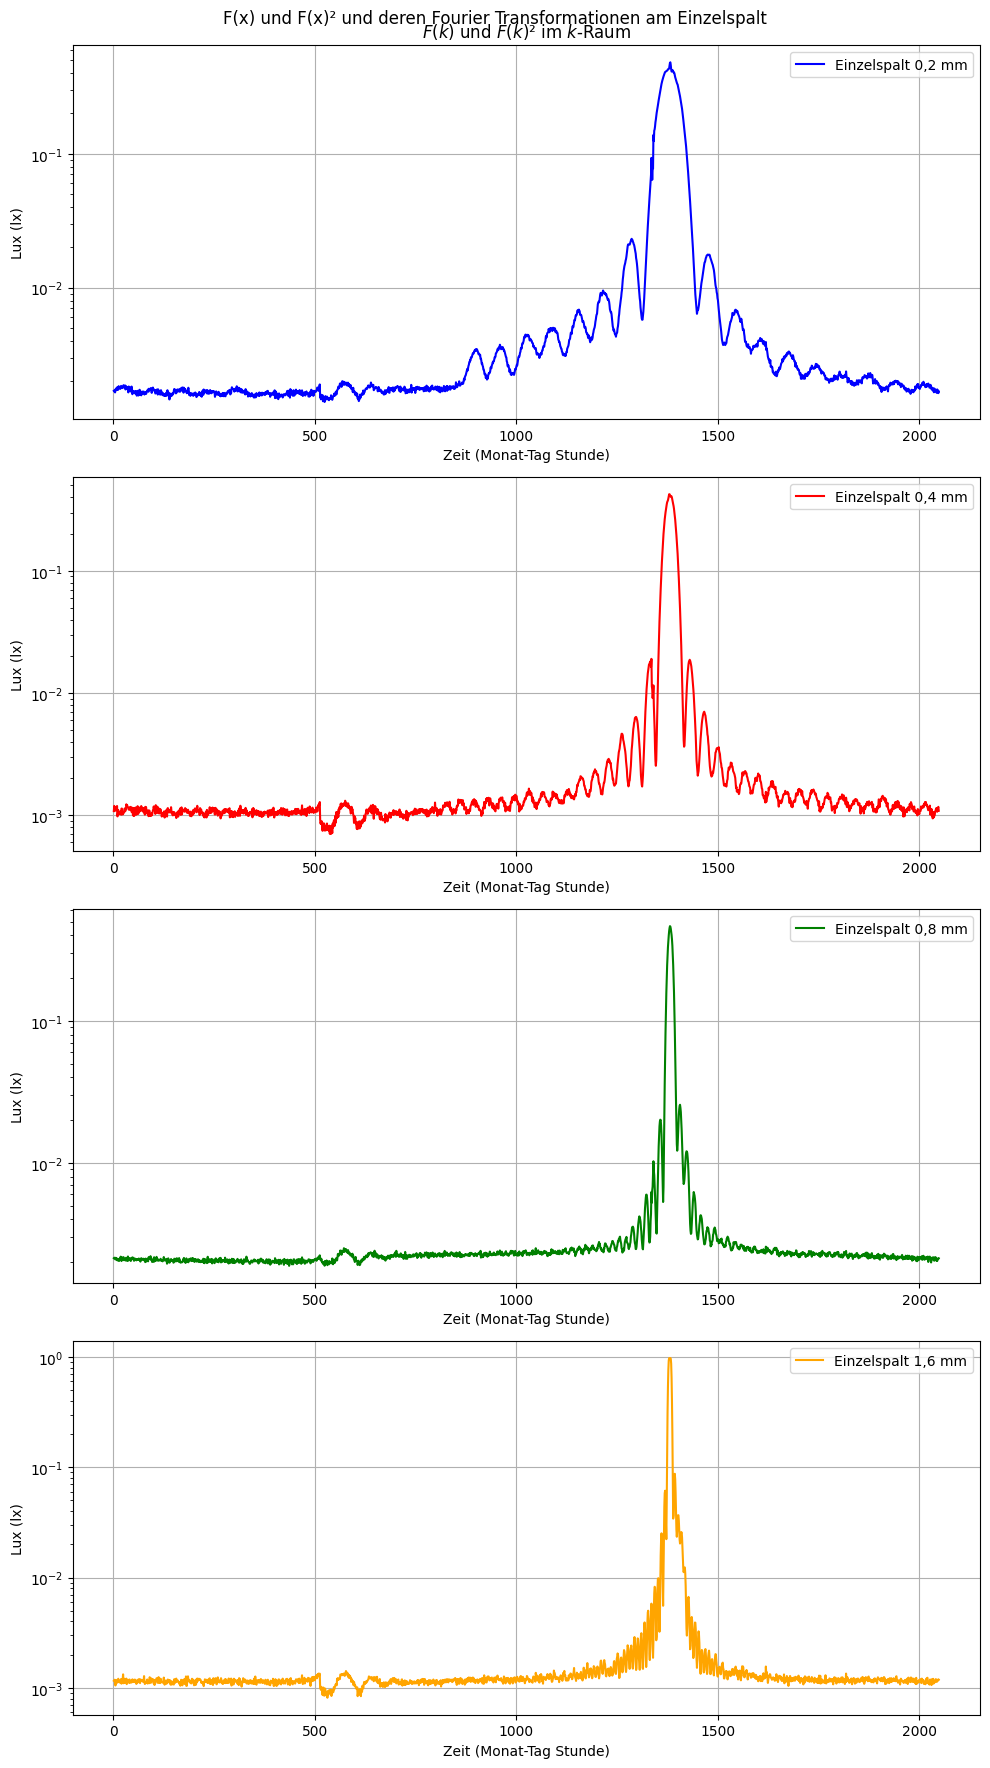

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung02mm.csv")
dt = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung04mm.csv")
dn = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung08mm.csv")
dm = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung16mm.csv")


# Plot für a_x
fig, axs = plt.subplots(4, 1, figsize=(10, 18))
fig.suptitle("F(x) und F(x)² und deren Fourier Transformationen am Einzelspalt")

axs[0].plot(df['x'], df['y'], label="Einzelspalt 0,2 mm", color="blue")
axs[0].set_yscale("log")
axs[0].set_xlabel("Zeit (Monat-Tag Stunde)")
axs[0].set_ylabel("Lux (lx)")
axs[0].set_title("$F(k)$ und $F(k)²$ im $k$-Raum")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(dt['x'], dt['y'], label="Einzelspalt 0,4 mm", color="red")
axs[1].set_yscale("log")
axs[1].set_xlabel("Zeit (Monat-Tag Stunde)")
axs[1].set_ylabel("Lux (lx)")
axs[1].grid(True)
axs[1].legend()

axs[2].plot(dn['x'], dn['y'], label="Einzelspalt 0,8 mm", color="green")
axs[2].set_yscale("log")
axs[2].set_xlabel("Zeit (Monat-Tag Stunde)")
axs[2].set_ylabel("Lux (lx)")
axs[2].grid(True)
axs[2].legend()

axs[3].plot(dm['x'], dm['y'], label="Einzelspalt 1,6 mm", color="orange")
axs[3].set_yscale("log")
axs[3].set_xlabel("Zeit (Monat-Tag Stunde)")
axs[3].set_ylabel("Lux (lx)")
axs[3].grid(True)
axs[3].legend()

fig.tight_layout()
plt.show()

## Fourier Transformation

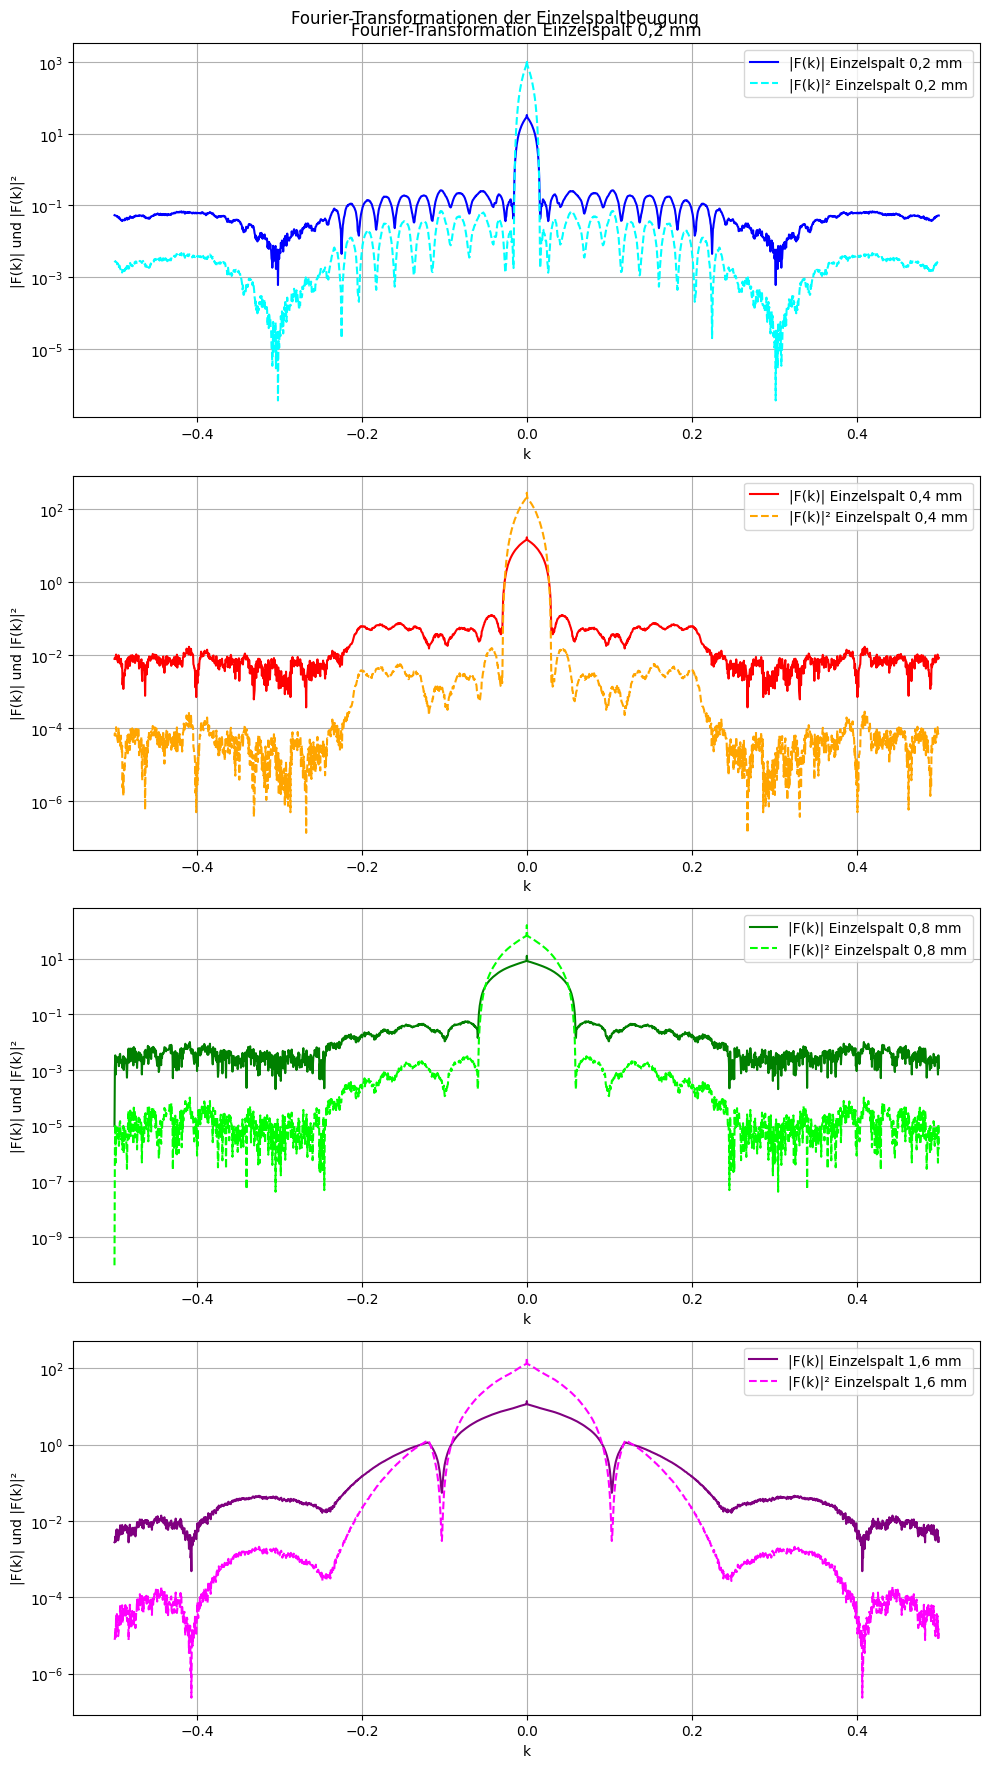

In [19]:
# Verwende bereits importierte numpy, matplotlib und die DataFrames (df, dt, dn, dm)
# (Die CSVs und Importe wurden bereits in einer früheren Zelle gemacht.)

# Fourier Transformationen mit numpy.fft (empfohlen gegenüber scipy.fftpack)
y_df = df['y'].values.astype(float)
y_dt = dt['y'].values.astype(float)
y_dn = dn['y'].values.astype(float)
y_dm = dm['y'].values.astype(float)

# Abstand in x (falls x regelmäßig, ansonsten mittlerer Abstand verwenden)
dx_df = np.mean(np.diff(df['x'].values))
dx_dt = np.mean(np.diff(dt['x'].values))
dx_dn = np.mean(np.diff(dn['x'].values))
dx_dm = np.mean(np.diff(dm['x'].values))

F_df = np.fft.fft(y_df)
F_dt = np.fft.fft(y_dt)
F_dn = np.fft.fft(y_dn)
F_dm = np.fft.fft(y_dm)

F2_df = np.abs(F_df)**2
F2_dt = np.abs(F_dt)**2
F2_dn = np.abs(F_dn)**2
F2_dm = np.abs(F_dm)**2

k_df = np.fft.fftfreq(len(y_df), d=dx_df)
k_dt = np.fft.fftfreq(len(y_dt), d=dx_dt)
k_dn = np.fft.fftfreq(len(y_dn), d=dx_dn)
k_dm = np.fft.fftfreq(len(y_dm), d=dx_dm)

# Für bessere Visualisierung: Frequenzen zentrieren (optional)
k_df_s = np.fft.fftshift(k_df)
k_dt_s = np.fft.fftshift(k_dt)
k_dn_s = np.fft.fftshift(k_dn)
k_dm_s = np.fft.fftshift(k_dm)

F_df_s = np.fft.fftshift(np.abs(F_df))
F_dt_s = np.fft.fftshift(np.abs(F_dt))
F_dn_s = np.fft.fftshift(np.abs(F_dn))
F_dm_s = np.fft.fftshift(np.abs(F_dm))

F2_df_s = np.fft.fftshift(F2_df)
F2_dt_s = np.fft.fftshift(F2_dt)
F2_dn_s = np.fft.fftshift(F2_dn)
F2_dm_s = np.fft.fftshift(F2_dm)

# Benutze anderen Namen für Achsen-Array, um keine früheren axs zu überschreiben
fig_ft, axs_ft = plt.subplots(4, 1, figsize=(10, 18))
fig_ft.suptitle("Fourier-Transformationen der Einzelspaltbeugung")

axs_ft[0].plot(k_df_s, F_df_s, label="|F(k)| Einzelspalt 0,2 mm", color="blue")
axs_ft[0].plot(k_df_s, F2_df_s, label="|F(k)|² Einzelspalt 0,2 mm", color="cyan", linestyle="--")
axs_ft[0].set_yscale("log")
axs_ft[0].set_xlabel("k")
axs_ft[0].set_ylabel("|F(k)| und |F(k)|²")
axs_ft[0].set_title("Fourier-Transformation Einzelspalt 0,2 mm")
axs_ft[0].grid(True)
axs_ft[0].legend()

axs_ft[1].plot(k_dt_s, F_dt_s, label="|F(k)| Einzelspalt 0,4 mm", color="red")
axs_ft[1].plot(k_dt_s, F2_dt_s, label="|F(k)|² Einzelspalt 0,4 mm", color="orange", linestyle="--")
axs_ft[1].set_yscale("log")
axs_ft[1].set_xlabel("k")
axs_ft[1].set_ylabel("|F(k)| und |F(k)|²")
axs_ft[1].grid(True)
axs_ft[1].legend()

axs_ft[2].plot(k_dn_s, F_dn_s, label="|F(k)| Einzelspalt 0,8 mm", color="green")
axs_ft[2].plot(k_dn_s, F2_dn_s, label="|F(k)|² Einzelspalt 0,8 mm", color="lime", linestyle="--")
axs_ft[2].set_yscale("log")
axs_ft[2].set_xlabel("k")
axs_ft[2].set_ylabel("|F(k)| und |F(k)|²")
axs_ft[2].grid(True)
axs_ft[2].legend()

axs_ft[3].plot(k_dm_s, F_dm_s, label="|F(k)| Einzelspalt 1,6 mm", color="purple")
axs_ft[3].plot(k_dm_s, F2_dm_s, label="|F(k)|² Einzelspalt 1,6 mm", color="magenta", linestyle="--")
axs_ft[3].set_yscale("log")
axs_ft[3].set_xlabel("k")
axs_ft[3].set_ylabel("|F(k)| und |F(k)|²")
axs_ft[3].grid(True)
axs_ft[3].legend()

fig_ft.tight_layout()
plt.show()

